In [1]:
import pandas as pd
df = pd.read_csv("rollrcoast.csv")
df

,RANK,ORDER,TOWER,ACRONYM,WORLD,AREA,DIFFICULTY,NUM,TIME,TIME [s],COMPLETION DATE,NOTES
0,1,196,Citadel of Heights and Depths,CoHaD,1,Ring 03,06 - Intense,6.13,221:10.20,13270.20,2023/09/23 17:57:32,NaN
1,2,222,Tower of Great Displeasure,ToGD,2,Zone 02,07 - Remorseless,7.17,127:18.67,7638.67,2024/05/25 13:27:14,NaN
2,3,276,"Tower of The Umbrella, The User",ToTUTU,1,Ring 08: The Starlit Archives,06 - Intense,6.32,114:39.27,6879.27,2025/06/14 22:00:30,NaN
3,4,204,Tower of Oblivion,ToO,1,Ring 04,06 - Intense,6.97,107:26.78,6446.78,2023/11/21 19:50:37,NaN
4,5,207,Tower of Guided Trials,ToGT,2,Zone 05,06 - Intense,6.52,107:11.47,6431.47,2023/12/09 20:33:55,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
335,336,8,Steeple of Low Woe,SoLW,1,Ring 01: Forgotten Ridge,02 - Medium,2.78,5:22.80,322.80,2022/05/15 16:18:04,NaN
336,337,17,Steeple of Pursuit,SoP,1,Ring 01: Forgotten Ridge,02 - Medium,2.86,5:22.33,322.33,2022/05/19 16:32:49,NaN
337,338,7,Steeple of Beginner's Journey,SoBJ,1,Ring 02: Garden of Eeshöl,01 - Easy,1.11,5:17.88,317.88,2022/05/15 15:43:51,NaN
338,339,70,Steeple of Astounding Sorcery,SoAS,2,Zone 02: Arcane Area,02 - Medium,2.53,5:08.58,308.58,2022/11/09 19:56:26,Revamp


In [2]:
print(df["TIME"])

0      221:10.20
1      127:18.67
2      114:39.27
3      107:26.78
4      107:11.47
         ...    
335      5:22.80
336      5:22.33
337      5:17.88
338      5:08.58
339      4:56.63
Name: TIME, Length: 340, dtype: str


In [3]:
print(df.dtypes)

RANK                 int64
ORDER                int64
TOWER                  str
ACRONYM                str
WORLD                int64
AREA                   str
DIFFICULTY             str
NUM                float64
TIME                   str
TIME [s]           float64
COMPLETION DATE        str
NOTES                  str
dtype: object


<Axes: xlabel='NUM', ylabel='TIME [s]'>

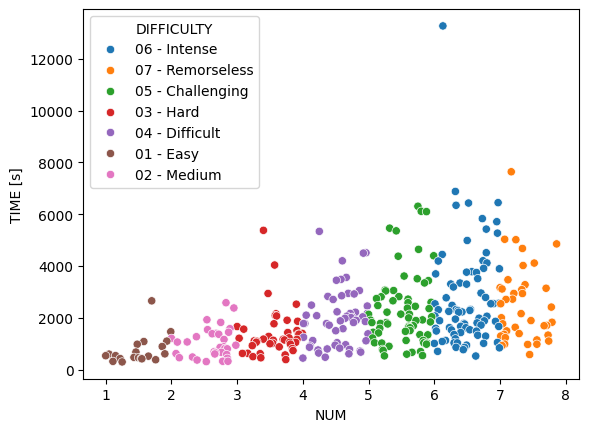

In [4]:
import seaborn as sns

sns.scatterplot(data=df,x="NUM",y="TIME [s]",hue="DIFFICULTY")



In [5]:
times = df["TIME [s]"]

print(times)

q1=times.quantile(0.25)
q3=times.quantile(0.75)
iqr = q3-q1

iqr

0      13270.20
1       7638.67
2       6879.27
3       6446.78
4       6431.47
         ...   
335      322.80
336      322.33
337      317.88
338      308.58
339      296.63
Name: TIME [s], Length: 340, dtype: float64


np.float64(1566.1275)

In [6]:
dg = df[(times < q3 + 1.5 * iqr) & (times > q1 - 1.5 * iqr)]

dg

,RANK,ORDER,TOWER,ACRONYM,WORLD,AREA,DIFFICULTY,NUM,TIME,TIME [s],COMPLETION DATE,NOTES
20,21,288,Tower of Power Laws,ToPL,2,Zone 10,07 - Remorseless,7.86,80:53.58,4853.58,2025/09/23 10:47:31,Current Hardest
21,22,214,Citadel of Scythe Recognition,CoSR,1,Ring 06,07 - Remorseless,7.34,77:58.24,4678.24,2024/03/29 21:52:24,NaN
22,23,117,Tower of Cyclonic Isles,ToCI,2,Zone 03: Paradise Atoll,05 - Challenging,5.76,77:22.87,4642.87,2023/01/19 19:08:23,NaN
23,24,137,Citadel of Corporate Enterprise,CoCE,2,Zone 05,06 - Intense,6.79,75:14.08,4514.08,2023/02/20 12:22:34,NaN
24,25,164,Tower of X Madness,ToXM,2,Zone 08,04 - Difficult,4.96,75:12.07,4512.07,2023/04/18 18:56:20,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
335,336,8,Steeple of Low Woe,SoLW,1,Ring 01: Forgotten Ridge,02 - Medium,2.78,5:22.80,322.80,2022/05/15 16:18:04,NaN
336,337,17,Steeple of Pursuit,SoP,1,Ring 01: Forgotten Ridge,02 - Medium,2.86,5:22.33,322.33,2022/05/19 16:32:49,NaN
337,338,7,Steeple of Beginner's Journey,SoBJ,1,Ring 02: Garden of Eeshöl,01 - Easy,1.11,5:17.88,317.88,2022/05/15 15:43:51,NaN
338,339,70,Steeple of Astounding Sorcery,SoAS,2,Zone 02: Arcane Area,02 - Medium,2.53,5:08.58,308.58,2022/11/09 19:56:26,Revamp


<Axes: xlabel='NUM', ylabel='TIME [s]'>

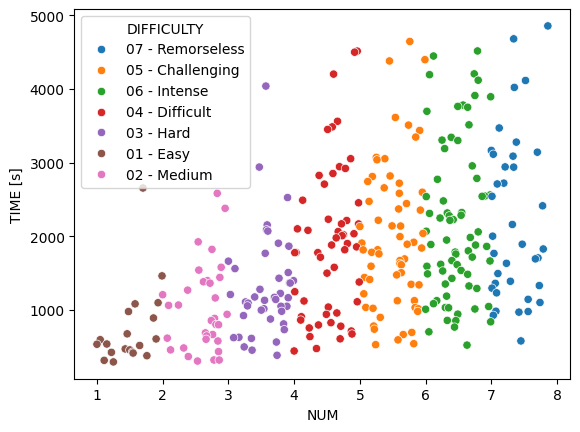

In [7]:
sns.scatterplot(data=dg,x="NUM",y="TIME [s]",hue="DIFFICULTY")

In [8]:
r = dg["NUM"].corr(dg["TIME [s]"])
print(f"r = {r}")

r = 0.45578295058344576


In [9]:
r = df["NUM"].corr(df["TIME [s]"])
print(f"r = {r}")

r = 0.4149884531128126


In [10]:
cohad = df.drop(index = 0)
print(cohad)

     RANK  ORDER                            TOWER ACRONYM  WORLD  \
1       2    222       Tower of Great Displeasure    ToGD      2   
2       3    276  Tower of The Umbrella, The User  ToTUTU      1   
3       4    204                Tower of Oblivion     ToO      1   
4       5    207           Tower of Guided Trials    ToGT      2   
5       6     99            Tower of Heiwana Kaze    ToHK      2   
..    ...    ...                              ...     ...    ...   
335   336      8               Steeple of Low Woe    SoLW      1   
336   337     17               Steeple of Pursuit     SoP      1   
337   338      7    Steeple of Beginner's Journey    SoBJ      1   
338   339     70    Steeple of Astounding Sorcery    SoAS      2   
339   340      1           Tower of A Simple Time   ToAST      1   

                              AREA        DIFFICULTY   NUM       TIME  \
1                          Zone 02  07 - Remorseless  7.17  127:18.67   
2    Ring 08: The Starlit Archives   

<Axes: xlabel='NUM', ylabel='TIME [s]'>

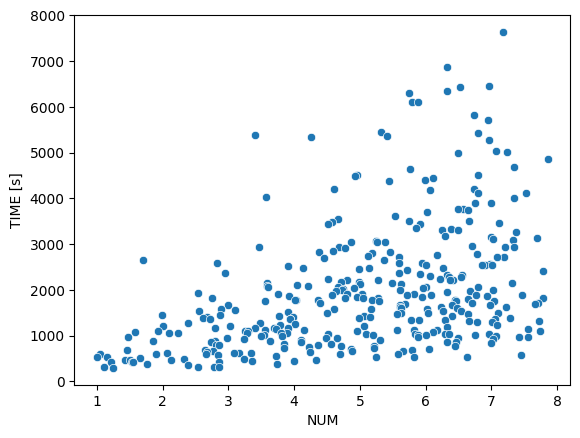

In [11]:
sns.scatterplot(data=cohad,x="NUM",y="TIME [s]")

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RANK             340 non-null    int64  
 1   ORDER            340 non-null    int64  
 2   TOWER            340 non-null    str    
 3   ACRONYM          340 non-null    str    
 4   WORLD            340 non-null    int64  
 5   AREA             340 non-null    str    
 6   DIFFICULTY       340 non-null    str    
 7   NUM              340 non-null    float64
 8   TIME             340 non-null    str    
 9   TIME [s]         340 non-null    float64
 10  COMPLETION DATE  340 non-null    str    
 11  NOTES            31 non-null     str    
dtypes: float64(2), int64(3), str(7)
memory usage: 60.2 KB


Loading specific dataset copy: rollrcoast.csv

          LINEAR REGRESSION RESULTS
R-value (Correlation Coefficient): 0.4150
R-squared (Coefficient of Det.):  0.1722
Linear Equation: TIME [s] = 370.9006 * NUM + 170.7329
For a tower with a difficulty of 7.20, the tower is expected to be beaten with a time of 2841.22 seconds, or 47:21.22.
For a tower with a difficulty of 7.68, the tower is expected to be beaten with a time of 3019.25 seconds, or 50:19.25.
For a tower with a difficulty of 8.00, the tower is expected to be beaten with a time of 3137.94 seconds, or 52:17.94.


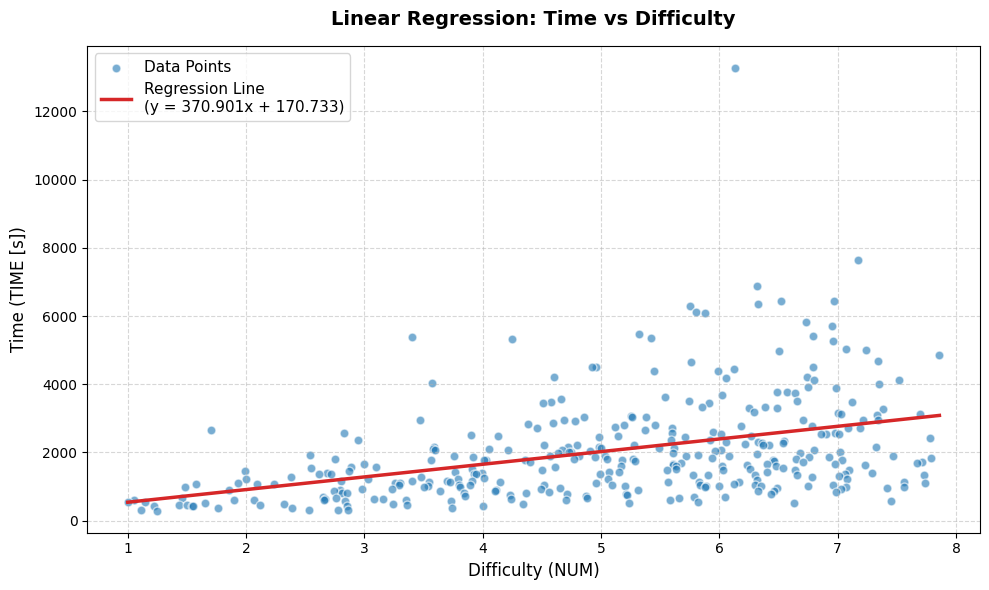

In [13]:
# Copy-pasted from Gemini
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Directly use the exact path for the 'Towers (1)' file
file_path = 'rollrcoast.csv'

print(f"Loading specific dataset copy: {file_path}")
df = pd.read_csv(file_path)

# 2. Define columns and ensure numeric formats
x_col = 'NUM'
y_col = 'TIME [s]'

# Convert columns to numeric, converting errors to NaN, then drop rows with NaNs
df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
df_clean = df.dropna(subset=[x_col, y_col])

x = df_clean[x_col]
y = df_clean[y_col]

# 3. Calculate Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# 4. Output Results

def linRegression(n):
    time = slope * n + intercept
    return time

print("\n" + "="*40)
print("          LINEAR REGRESSION RESULTS")
print("="*40)
print(f"R-value (Correlation Coefficient): {r_value:.4f}")
print(f"R-squared (Coefficient of Det.):  {r_value**2:.4f}")
print(f"Linear Equation: TIME [s] = {slope:.4f} * NUM + {intercept:.4f}")
print("="*40)
n = 7.20
minutes = linRegression(n)//60
print(f"For a tower with a difficulty of {n:.2f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")
n = 7.68
minutes = linRegression(n)//60
print(f"For a tower with a difficulty of {n:.2f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")
n = 8.00
minutes = linRegression(n)//60
print(f"For a tower with a difficulty of {n:.2f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")

# 5. Create the Visualization
plt.figure(figsize=(10, 6))

# Plot the individual data points
plt.scatter(x, y, color='#1f77b4', alpha=0.6, edgecolors='w', s=40, label='Data Points')

# Plot the fitted regression line
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept
plt.plot(line_x, line_y, color='#d62728', linewidth=2.5, 
         label=f'Regression Line\n(y = {slope:.3f}x + {intercept:.3f})')

# Labeling and styling the plot
plt.title('Linear Regression: Time vs Difficulty', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Difficulty (NUM)', fontsize=12)
plt.ylabel('Time (TIME [s])', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

# Tight layout to avoid overlapping or clipping
plt.tight_layout()
plt.show()

Loading specific dataset copy: rollrcoast.csv

          LINEAR REGRESSION RESULTS
R-value (Correlation Coefficient): 0.1683
R-squared (Coefficient of Det.):  0.0283
Linear Equation: TIME [s] = 2.5937 * # + 1597.2843
If I beat tower #350, the tower is expected to be beaten with a time of 2505.07 seconds, or 41:45.07.
If I beat tower #400, the tower is expected to be beaten with a time of 2634.75 seconds, or 43:54.75.
If I beat tower #420, the tower is expected to be beaten with a time of 2686.62 seconds, or 44:46.62.


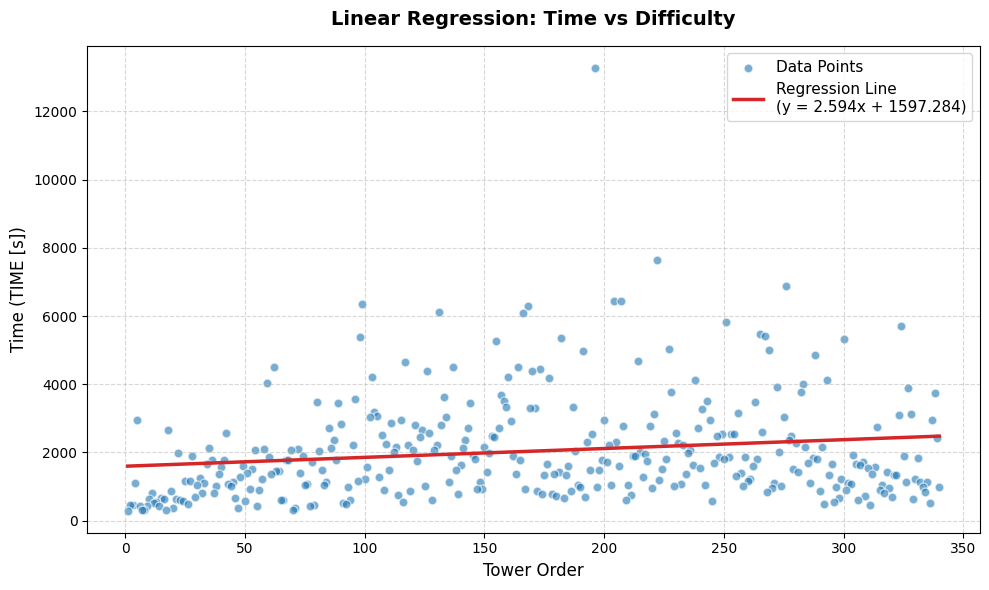

In [14]:
# 1. Directly use the exact path for the 'Towers (1)' file
file_path = 'rollrcoast.csv'

print(f"Loading specific dataset copy: {file_path}")
df = pd.read_csv(file_path)

# 2. Define columns and ensure numeric formats
x_col = 'ORDER'
y_col = 'TIME [s]'

# Convert columns to numeric, converting errors to NaN, then drop rows with NaNs
df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
df_clean = df.dropna(subset=[x_col, y_col])

x = df_clean[x_col]
y = df_clean[y_col]

# 3. Calculate Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# 4. Output Results

def linRegression(n):
    time = slope * n + intercept
    return time

print("\n" + "="*40)
print("          LINEAR REGRESSION RESULTS")
print("="*40)
print(f"R-value (Correlation Coefficient): {r_value:.4f}")
print(f"R-squared (Coefficient of Det.):  {r_value**2:.4f}")
print(f"Linear Equation: TIME [s] = {slope:.4f} * # + {intercept:.4f}")
print("="*40)
n = 350
minutes = linRegression(n)//60
print(f"If I beat tower #{n:.0f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")
n = 400
minutes = linRegression(n)//60
print(f"If I beat tower #{n:.0f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")
n = 420
minutes = linRegression(n)//60
print(f"If I beat tower #{n:.0f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")

# 5. Create the Visualization
plt.figure(figsize=(10, 6))

# Plot the individual data points
plt.scatter(x, y, color='#1f77b4', alpha=0.6, edgecolors='w', s=40, label='Data Points')

# Plot the fitted regression line
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept
plt.plot(line_x, line_y, color='#d62728', linewidth=2.5, 
         label=f'Regression Line\n(y = {slope:.3f}x + {intercept:.3f})')

# Labeling and styling the plot
plt.title('Linear Regression: Time vs Difficulty', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tower Order', fontsize=12)
plt.ylabel('Time (TIME [s])', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

# Tight layout to avoid overlapping or clipping
plt.tight_layout()
plt.show()